In [4]:
import os

base_dir = 'data/raw/chest_xray'

for split in ['train', 'test', 'val']:
    normal_count = len(os.listdir(f'{base_dir}/{split}/NORMAL'))
    pneumonia_count = len(os.listdir(f'{base_dir}/{split}/PNEUMONIA'))
    print(f"{split.upper()}: Normal={normal_count}, Pneumonia={pneumonia_count}")

TRAIN: Normal=1341, Pneumonia=3875
TEST: Normal=234, Pneumonia=390
VAL: Normal=8, Pneumonia=8


In [2]:
import os
print(os.getcwd())
print(os.listdir('..'))

/Users/devkushwah/Desktop/PulmoScan
['PulmoScan', '.DS_Store', '.localized', 'Django_project', 'java', 'Screenshot 2026-09-03 at 2.24.20\u202fAM.png', 'Dev.html', 'Screenshot 2026-09-03 at 7.36.46\u202fPM.png']


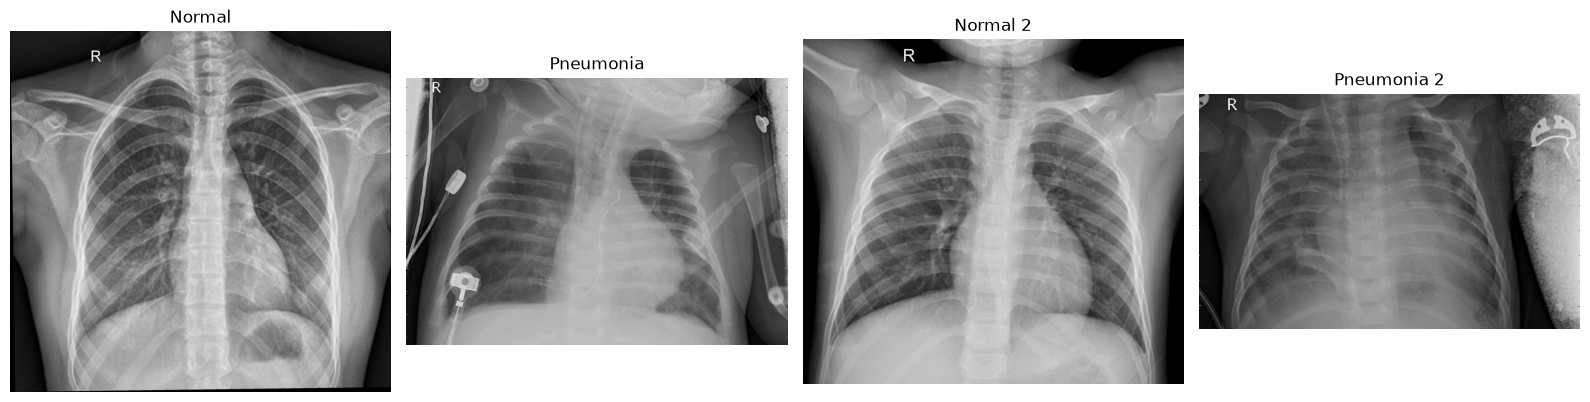

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

normal_img = os.listdir(f'{base_dir}/train/NORMAL')[0]
pneumonia_img = os.listdir(f'{base_dir}/train/PNEUMONIA')[0]

axes[0].imshow(mpimg.imread(f'{base_dir}/train/NORMAL/{normal_img}'), cmap='gray')
axes[0].set_title('Normal')
axes[0].axis('off')

axes[1].imshow(mpimg.imread(f'{base_dir}/train/PNEUMONIA/{pneumonia_img}'), cmap='gray')
axes[1].set_title('Pneumonia')
axes[1].axis('off')

# Ek aur normal aur pneumonia dikhate hai comparison ke liye
normal_img2 = os.listdir(f'{base_dir}/train/NORMAL')[5]
pneumonia_img2 = os.listdir(f'{base_dir}/train/PNEUMONIA')[5]

axes[2].imshow(mpimg.imread(f'{base_dir}/train/NORMAL/{normal_img2}'), cmap='gray')
axes[2].set_title('Normal 2')
axes[2].axis('off')

axes[3].imshow(mpimg.imread(f'{base_dir}/train/PNEUMONIA/{pneumonia_img2}'), cmap='gray')
axes[3].set_title('Pneumonia 2')
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 150
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False  # X-ray me flip mat karo, lungs left-right specific hote hai
)

test_val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    f'{base_dir}/train',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    color_mode='grayscale'
)

test_generator = test_val_datagen.flow_from_directory(
    f'{base_dir}/test',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential([
    Input(shape=(img_size, img_size, 1)),  # 1 channel kyunki grayscale
    
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu', name='last_conv_layer'),  # Grad-CAM ke liye naam diya
    MaxPooling2D(2,2),
    
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv_layer (Conv2D)        │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,043,329 (3.98 MB)

 Trainable params: 1,043,329 (3.98 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [11]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    class_weight=class_weights_dict
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 197ms/step - accuracy: 0.6315 - loss: 0.5889 - val_accuracy: 0.8269 - val_loss: 0.3778
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 203ms/step - accuracy: 0.8643 - loss: 0.3069 - val_accuracy: 0.8686 - val_loss: 0.3170
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 209ms/step - accuracy: 0.9089 - loss: 0.2233 - val_accuracy: 0.8798 - val_loss: 0.3168
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 209ms/step - accuracy: 0.9229 - loss: 0.1944 - val_accuracy: 0.8365 - val_loss: 0.4191
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 211ms/step - accuracy: 0.9275 - loss: 0.1811 - val_accuracy: 0.8974 - val_loss: 0.3022
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 212ms/step - accuracy: 0.9208 - loss: 0.1872 - val_accuracy: 0.8878 - val_loss: 0.3349
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 213ms/step - accuracy: 0.9260 - loss: 0.1829 - val_accuracy: 0.9135 - val_loss: 0.2664
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 214ms/step - accuracy: 0.9375 - loss: 0

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions nikalo test set pe
test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_generator.classes

print(classification_report(true_classes, predicted_classes, target_names=['NORMAL', 'PNEUMONIA']))

print("\nConfusion Matrix:")
print(confusion_matrix(true_classes, predicted_classes))

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step
              precision    recall  f1-score   support

      NORMAL       0.95      0.66      0.78       234
   PNEUMONIA       0.83      0.98      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.82      0.84       624
weighted avg       0.87      0.86      0.85       624


Confusion Matrix:
[[155  79]
 [  8 382]]


In [25]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def get_gradcam_heatmap(model, img_array, last_conv_layer_name='last_conv_layer'):
    # Model ko explicitly rebuild karo Input se, taaki .input attribute ki zaroorat na pade
    inputs = tf.keras.Input(shape=img_array.shape[1:])
    x = inputs
    last_conv_output = None
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            last_conv_output = x
    
    grad_model = tf.keras.models.Model(inputs=inputs, outputs=[last_conv_output, x])
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

Heatmap shape: (15, 15)


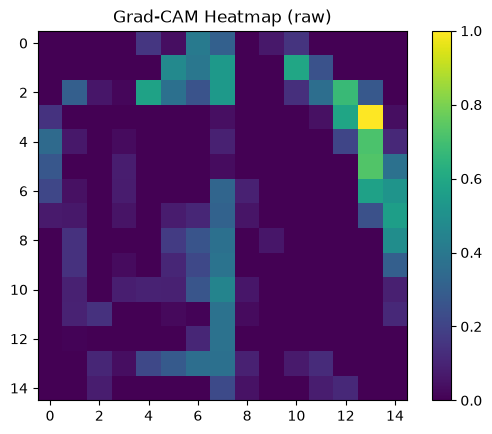

In [26]:
test_generator.reset()
test_images, test_labels = next(test_generator)
sample_img = test_images[0:1]

heatmap = get_gradcam_heatmap(model, sample_img)
print("Heatmap shape:", heatmap.shape)
plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap (raw)")
plt.colorbar()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


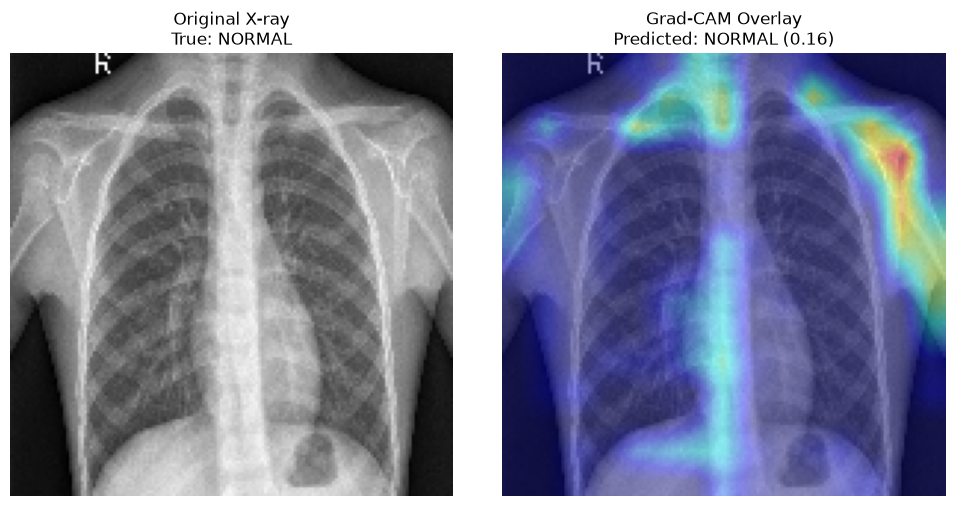

In [27]:
def overlay_gradcam(img_array, heatmap, alpha=0.4):
    # Original image ko 0-255 range me convert karo
    img = np.uint8(255 * img_array[0])
    if img.shape[-1] == 1:
        img = np.squeeze(img, axis=-1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    
    # Heatmap ko image size tak resize karo
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    
    # Heatmap ko color map apply karo (jet colormap = blue-green-yellow-red)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Overlay karo
    overlayed = cv2.addWeighted(img_rgb, 1-alpha, heatmap_colored, alpha, 0)
    return overlayed

# Test karo
overlayed_img = overlay_gradcam(sample_img, heatmap)

# Prediction bhi nikal lo
pred = model.predict(sample_img)[0][0]
pred_label = "PNEUMONIA" if pred > 0.5 else "NORMAL"
true_label = "PNEUMONIA" if test_labels[0] == 1 else "NORMAL"

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(np.squeeze(sample_img[0]), cmap='gray')
axes[0].set_title(f'Original X-ray\nTrue: {true_label}')
axes[0].axis('off')

axes[1].imshow(overlayed_img)
axes[1].set_title(f'Grad-CAM Overlay\nPredicted: {pred_label} ({pred:.2f})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [29]:
# Ek Pneumonia image dhundo test batch me
pneumonia_idx = np.where(test_labels == 1)[0]
if len(pneumonia_idx) > 0:
    idx = pneumonia_idx[0]
    sample_img2 = test_images[idx:idx+1]
    
    heatmap2 = get_gradcam_heatmap(model, sample_img2)
    overlayed_img2 = overlay_gradcam(sample_img2, heatmap2)
    
    pred2 = model.predict(sample_img2)[0][0]
    pred_label2 = "PNEUMONIA" if pred2 > 0.5 else "NORMAL"
    true_label2 = "PNEUMONIA" if test_labels[idx] == 1 else "NORMAL"
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(np.squeeze(sample_img2[0]), cmap='gray')
    axes[0].set_title(f'Original X-ray\nTrue: {true_label2}')
    axes[0].axis('off')
    
    axes[1].imshow(overlayed_img2)
    axes[1].set_title(f'Grad-CAM Overlay\nPredicted: {pred_label2} ({pred2:.2f})')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Is batch me koi Pneumonia image nahi mili, dubara run karo")

Is batch me koi Pneumonia image nahi mili, dubara run karo


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


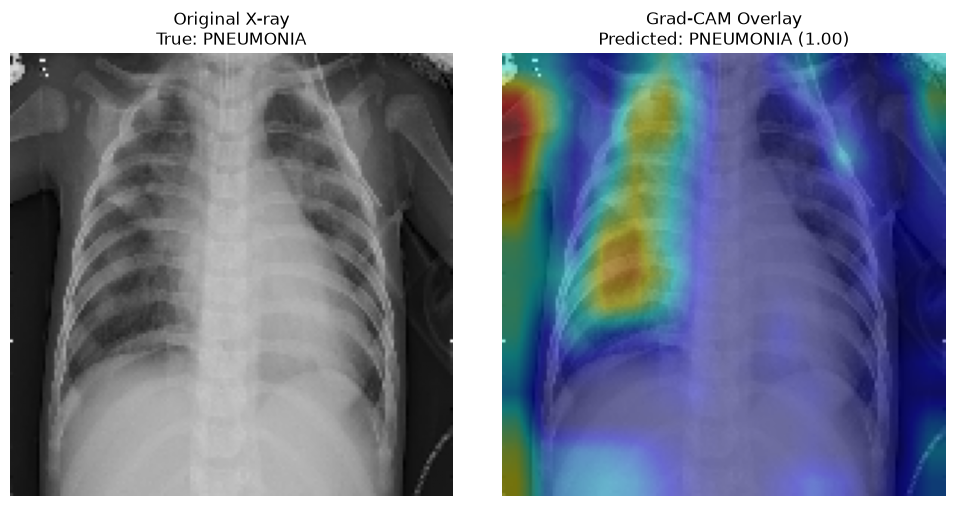

In [30]:
import os

# Directly ek Pneumonia image file load karo test folder se
pneumonia_files = os.listdir(f'{base_dir}/test/PNEUMONIA')
img_path = f'{base_dir}/test/PNEUMONIA/{pneumonia_files[0]}'

from tensorflow.keras.preprocessing.image import load_img, img_to_array

img = load_img(img_path, target_size=(img_size, img_size), color_mode='grayscale')
img_array = img_to_array(img) / 255.0
sample_img2 = np.expand_dims(img_array, axis=0)

heatmap2 = get_gradcam_heatmap(model, sample_img2)
overlayed_img2 = overlay_gradcam(sample_img2, heatmap2)

pred2 = model.predict(sample_img2)[0][0]
pred_label2 = "PNEUMONIA" if pred2 > 0.5 else "NORMAL"

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(np.squeeze(sample_img2[0]), cmap='gray')
axes[0].set_title('Original X-ray\nTrue: PNEUMONIA')
axes[0].axis('off')

axes[1].imshow(overlayed_img2)
axes[1].set_title(f'Grad-CAM Overlay\nPredicted: {pred_label2} ({pred2:.2f})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [31]:
model.save('../models/pneumonia_model.h5')
print("Model saved successfully!")

Model saved successfully!


In [32]:
model.save('../models/pneumonia_model.keras')
print("Model saved in native Keras format!")

Model saved in native Keras format!


In [33]:
import os
print(os.listdir('../models'))

['pneumonia_model.h5', 'pneumonia_model.keras']
